**NOTEBOOK BY**

Vinicius Moraes de Carvalho

Camila Aya Saito

Guilherme Vaz O Tarata

Pedro Henrique G Moracci

In [ ]:
#Download Dataset
!pip install kaggle -q
import os

os.environ['KAGGLE_USERNAME'] = "drysaliva"
os.environ['KAGGLE_KEY'] = "c5bf9cb0ce67bb03eed03787d9e96cf7"

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

In [ ]:
!kaggle datasets download -d mahdimashayekhi/social-media-vs-productivity --unzip

Dataset URL: https://www.kaggle.com/datasets/mahdimashayekhi/social-media-vs-productivity
License(s): CC-BY-NC-SA-4.0
  0% 0.00/2.26M [00:00<?, ?B/s]
100% 2.26M/2.26M [00:00<00:00, 528MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### **ANALISE EXPLORATÓRIA DE DADOS**

Realizaremos uma análise exploratória para entender a estrutura dos dados, identificar valores ausentes e visualizar as distribuições das variáveis de interesse.


In [ ]:
# leitura dos dados
df = pd.read_csv('social_media_vs_productivity.csv')
print("Informações gerais do dataframe:")
df.info()
print("\n")
df

Informações gerais do dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12 

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711


In [ ]:
# quantidade de dados faltantes em cada coluna
print('Dados Faltantes por Coluna:')
print(df.isnull().sum())
print('\n')

Dados Faltantes por Coluna:
age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64




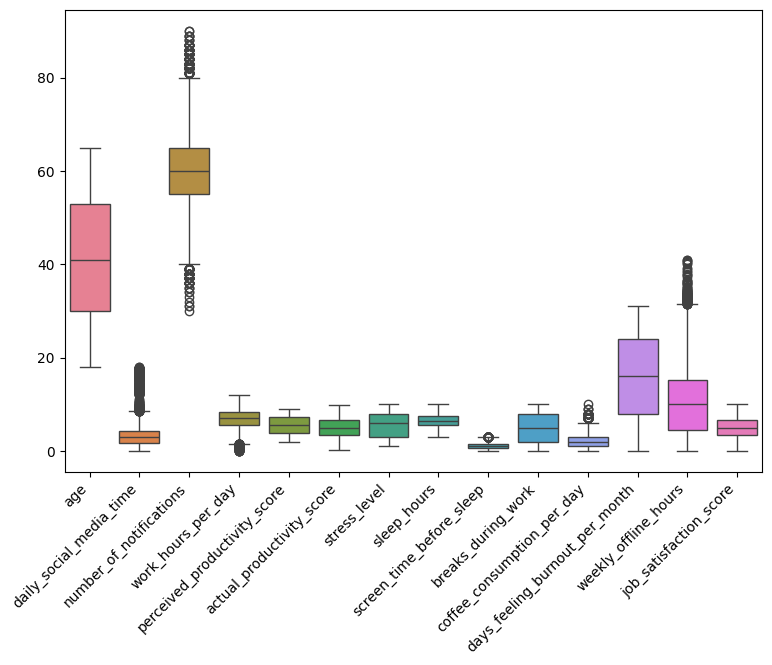

In [ ]:
# Box-plots das variáveis quantitativas do dataset
plt.figure(figsize=(9,6))
df_num = df.select_dtypes(include='number')
ax = sns.boxplot(data=df_num)
plt.xticks(rotation=45, ha='right')
plt.savefig('grafico_pizza_genero.png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# dados estatísticos de cada item do dataset
df_num.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,30000.000000,27235.000000,30000.000000,30000.000000,28386.000000,27635.000000,28096.000000,27402.000000,27789.000000,30000.000000,30000.000000,30000.000000,30000.000000,27270.000000
mean,41.486867,3.113418,59.958767,6.990792,5.510488,4.951805,5.514059,6.500247,1.025568,4.992200,1.999300,15.557067,10.360655,4.964901
std,13.835221,2.074813,7.723772,1.997736,2.023470,1.883378,2.866344,1.464004,0.653355,3.173737,1.410047,9.252956,7.280415,2.121194
min,18.000000,0.000000,30.000000,0.000000,2.000252,0.296812,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.639566,55.000000,5.643771,3.757861,3.373284,3.000000,5.493536,0.528490,2.000000,1.000000,8.000000,4.541872,3.363580
50%,41.000000,3.025913,60.000000,6.990641,5.525005,4.951742,6.000000,6.498340,1.006159,5.000000,2.000000,16.000000,10.013677,4.951049
75%,53.000000,4.368917,65.000000,8.354725,7.265776,6.526342,8.000000,7.504143,1.477221,8.000000,3.000000,24.000000,15.300809,6.581323
max,65.000000,17.973256,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,10.000000,31.000000,40.964769,10.000000


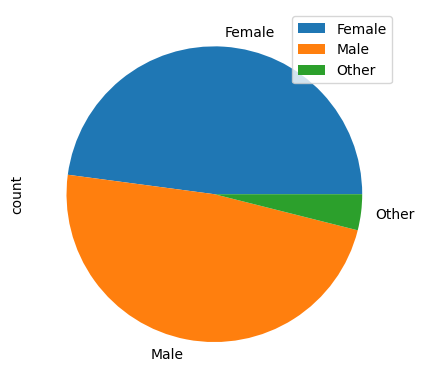

In [ ]:
tab1 = pd.crosstab(index=df['gender'], columns='count')
tab1.plot.pie(y='count')



<Axes: ylabel='count'>

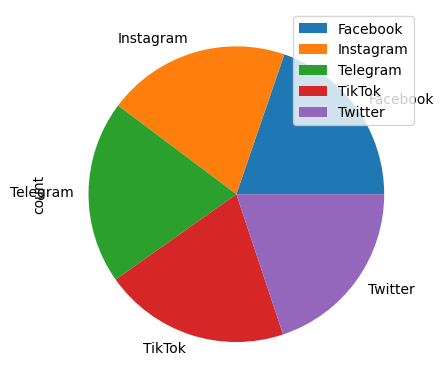

In [ ]:
tab2 = pd.crosstab(index=df['social_platform_preference'], columns='count')
tab2.plot.pie(y='count')

### **Tratamento dos dados**

Para garantir a integridade da análise, serão excluídas as linhas com dados nulos para, depois, retirar uma amostra aleatória de 500 dados para aplicação dos testes de hipóteses.

In [ ]:
df_limpo = df.dropna()
df_limpo

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
6,56,Female,Unemployed,4.381070,TikTok,60,3.902309,6.420989,5.976408,7.0,7.549849,2.252624,4,False,False,4,20,24.084905,5.501373
7,36,Female,Education,4.089168,Twitter,49,6.560467,2.681830,2.446927,4.0,6.325507,0.747998,2,False,False,4,29,8.419648,3.444376
10,28,Male,IT,3.341559,Twitter,57,11.022035,8.940636,7.983252,4.0,3.952547,1.028640,5,True,True,1,3,13.514515,9.414637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29988,34,Male,IT,3.562316,Twitter,59,7.685305,3.233504,2.932739,9.0,5.689819,2.333739,2,False,False,1,30,3.687407,2.123211
29992,44,Female,Unemployed,1.648825,TikTok,39,6.547262,5.900434,5.164050,9.0,8.803968,0.305591,9,True,False,2,1,24.743560,6.073588
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237


In [ ]:
print('Estatísticas descritivas:')
df_limpo.describe()

Estatísticas descritivas:


,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000
mean,41.462926,3.122575,59.974288,6.989841,5.505523,4.944530,5.512592,6.506391,1.025165,5.001113,2.004803,15.540119,10.369978,4.945884
std,13.835084,2.080257,7.788587,1.995280,2.026415,1.888881,2.866152,1.455486,0.654821,3.183056,1.409725,9.240403,7.253499,2.130109
min,18.000000,0.000000,32.000000,0.000000,2.000252,0.298476,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.647730,55.000000,5.661512,3.745743,3.352817,3.000000,5.503544,0.526338,2.000000,1.000000,8.000000,4.605728,3.319909
50%,41.000000,3.036425,60.000000,6.985661,5.515816,4.936777,6.000000,6.510388,1.010674,5.000000,2.000000,16.000000,10.010172,4.941100
75%,53.000000,4.367746,65.000000,8.347780,7.259461,6.531210,8.000000,7.492182,1.473942,8.000000,3.000000,24.000000,15.306980,6.584756
max,65.000000,17.817948,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,9.000000,31.000000,40.964769,10.000000


In [ ]:
# tiro uma amostra de tamanho 500 com uma semente fixa para replicação do experimento

amostra = df_limpo.sample(n=500, random_state=42)
amostra

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
3661,36,Female,Student,5.127717,Twitter,69,7.979210,2.646607,2.321966,2.0,7.568008,0.330345,8,True,False,2,23,15.221973,3.132537
13279,21,Female,Health,1.352347,Telegram,74,10.173016,6.982860,6.639901,4.0,8.328132,1.368552,6,False,True,2,1,16.120166,6.200354
29735,23,Female,Student,4.938801,TikTok,73,7.729134,3.072162,2.423302,9.0,5.171517,0.452840,6,False,False,3,15,5.420083,2.196394
14700,36,Female,Unemployed,10.832153,Twitter,62,8.324962,2.951966,2.643793,1.0,7.222108,1.379074,4,False,False,3,25,17.623549,0.344564
7091,41,Male,Finance,3.672656,Instagram,58,5.334852,3.881889,3.242198,8.0,5.920233,0.608256,5,True,False,1,15,0.859844,5.352764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22790,48,Female,Unemployed,3.945927,Facebook,57,9.085522,2.652034,3.021248,3.0,4.641187,0.156878,8,True,False,0,7,0.000000,2.810902
25944,18,Female,Student,3.208933,Telegram,56,4.183471,2.845339,2.613213,10.0,6.904272,1.323652,2,False,False,2,21,23.107491,2.646055
8107,36,Male,Unemployed,1.875952,Telegram,66,5.248204,7.158184,6.883555,5.0,7.595462,0.000000,1,False,False,2,25,6.138754,5.743424
22620,62,Male,IT,3.318898,TikTok,62,5.357570,5.383148,3.848019,8.0,6.448238,1.017036,5,False,False,2,24,16.866316,2.981351


In [ ]:
# dados estatísticos da amostra
amostra.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,41.75200,3.228255,60.640000,6.991756,5.432160,4.846840,5.400000,6.502335,1.007870,5.002000,1.958000,16.000000,10.334049,4.876312
std,13.81217,2.223461,7.727472,1.931548,2.049912,1.912217,2.849604,1.469923,0.652455,3.223473,1.445134,9.223565,7.202134,2.126384
min,18.00000,0.000000,40.000000,0.000000,2.015057,0.792545,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.045191
25%,30.00000,1.724132,56.000000,5.742693,3.522324,3.201662,3.000000,5.487585,0.546488,2.000000,1.000000,8.000000,4.409745,3.252245
50%,42.00000,3.182977,61.000000,6.948795,5.416883,4.819988,5.000000,6.486221,0.941254,5.000000,2.000000,16.000000,9.971228,4.876188
75%,53.00000,4.457219,65.250000,8.248943,7.207721,6.500139,8.000000,7.568047,1.424064,8.000000,3.000000,24.000000,15.395250,6.563149
max,65.00000,17.724981,89.000000,12.000000,8.998854,8.738220,10.000000,10.000000,3.000000,10.000000,6.000000,31.000000,33.585258,10.000000


# **Teste para investigar a relação entre o uso de plataformas de mídia social e a produtividade dos indivíduos, utilizando o conjunto de dados fornecido.**

**H0**: Não há diferença significativa na
produtividade entre indivíduos que utilizam
diferentes plataformas de mídia social

**H1**: Existe uma diferença significativa na
produtividade  entre pelo menos dois grupos
de indivíduos que utilizam diferentes plataformas de mídia social

Visualização:

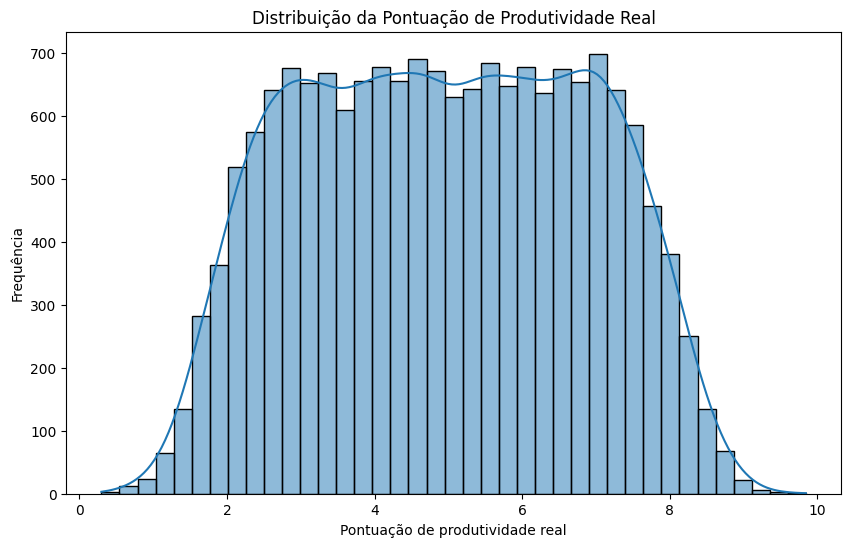

In [ ]:
#Distribuição da pontuação de produtividade real

plt.figure(figsize=(10,6))
sns.histplot(df_limpo['actual_productivity_score'], kde=True)

plt.title('Distribuição da Pontuação de Produtividade Real')
plt.xlabel('Pontuação de produtividade real')

plt.ylabel('Frequência')
plt.show()
plt.close()

:**Visualmente, a distribuição da produtividade real se
assemelha a uma curva Normal**

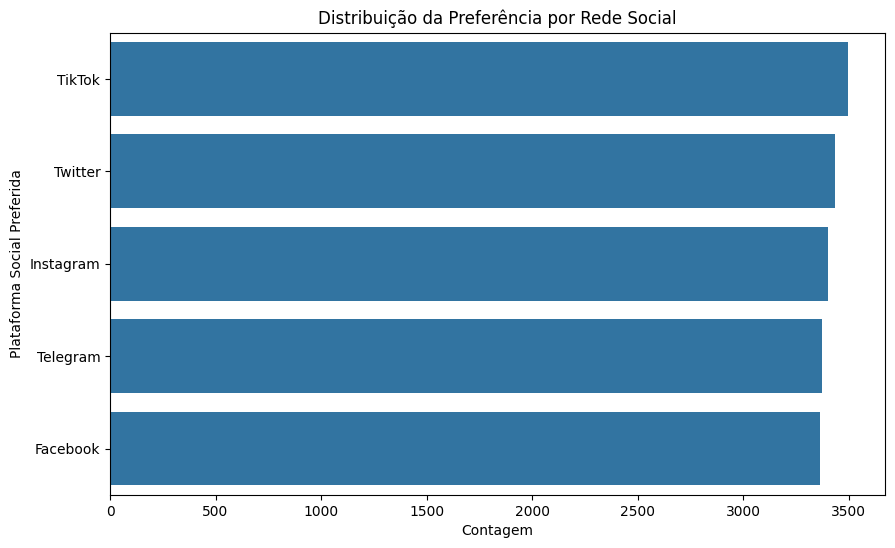

In [ ]:
#Distribuição da preferência por plataforma social
plt.figure(figsize=(10, 6))

sns.countplot(data=df_limpo,y='social_platform_preference',order=df_limpo['social_platform_preference'].value_counts().index)
plt.title('Distribuição da Preferência por Rede Social')
plt.xlabel('Contagem')===
plt.ylabel('Plataforma Social Preferida')
plt.show()
plt.close()

**As plataformas
(TikTok, Telegram, Instagram, Twitter, Facebook) têm uma distribuição
relativamente equilibrada de usuários.**

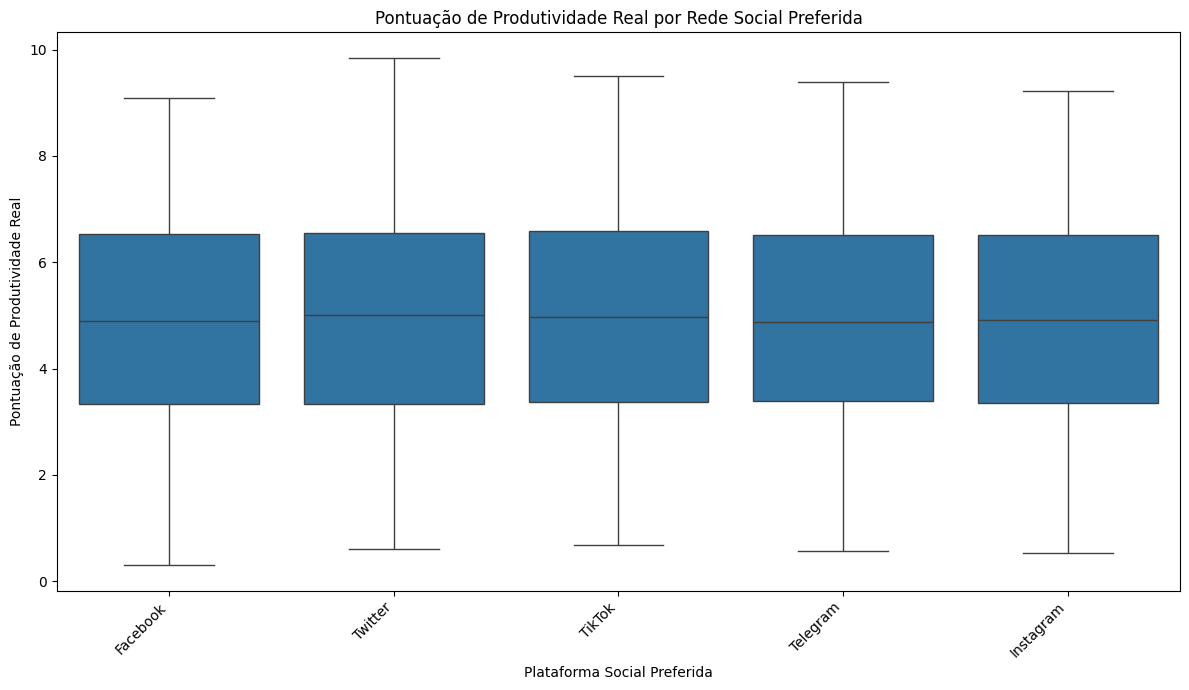

In [ ]:
#Box plot da produtividade real por plataforma social preferida
plt.figure(figsize=(12,7))
sns.boxplot(data=df_limpo,x='social_platform_preference',y='actual_productivity_score')
plt.title('Pontuação de Produtividade Real por Rede Social Preferida')
plt.xlabel('Plataforma Social Preferida')
plt.ylabel('Pontuação de Produtividade Real')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()
plt.close()

**Visualmente, as medianas entre os grupos parecem
ser bastante próximas.**

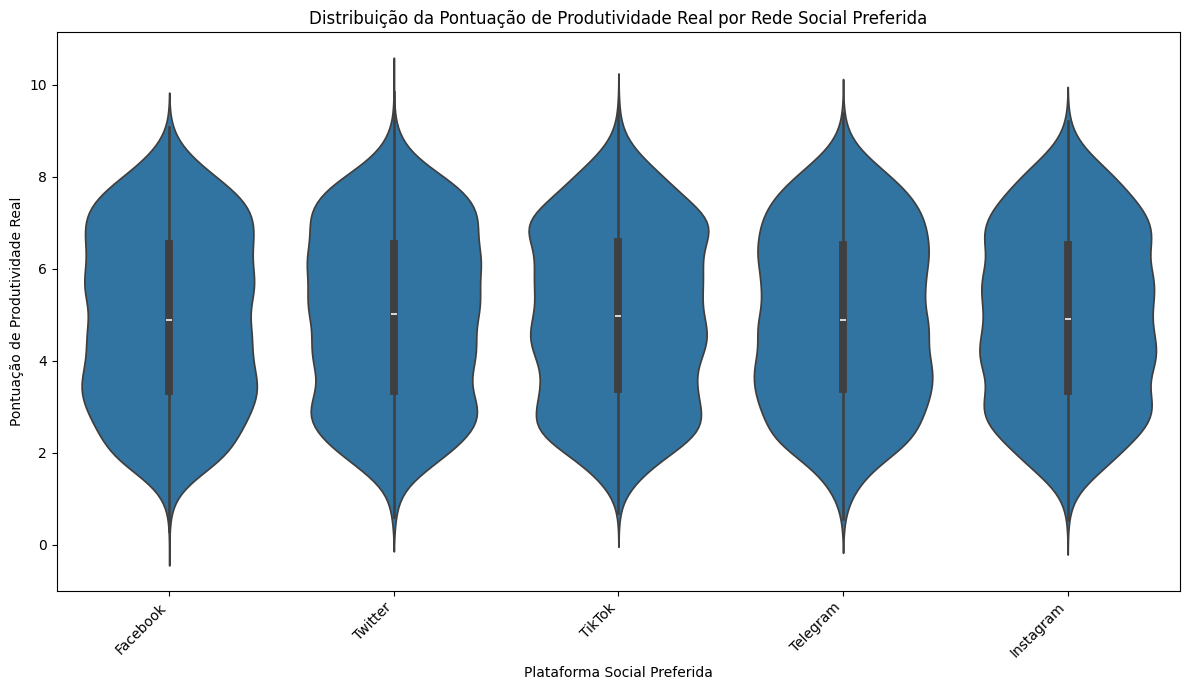

In [ ]:
# Violin plot da produtividade real por rede social preferida
plt.figure(figsize=(12,7))

sns.violinplot(data=df_limpo,x='social_platform_preference',y='actual_productivity_score')
plt.title('Distribuição da Pontuação de Produtividade Real por Rede Social Preferida')
plt.xlabel('Plataforma Social Preferida')
plt.ylabel('Pontuação de Produtividade Real')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()
plt.close()

***a densidade da distribuição, confirma que as
distribuições de produtividade entre as plataformas são semelhantes.***

### **Teste de Normalidade**
Antes de escolher o teste inferencial adequado, verificaremos a normalidade da variável
actual_productivity_score para cada grupo de social_platform_preference. Faremos uma amostragem de 500 dados por grupo para aplicar o teste de Shapiro-Wilk,
que é mais adequado para amostras de tamanho moderado e menos sensível a pequenos desvios em grandes populações.

**H0**: Os dados seguem uma distribuição normal.

**H1**: Os dados não seguem uma distribuição normal.

---Teste de Normalidade por Rede Social(com amostragem) ---


Rede Social: Twitter
Shapiro-Wilk: Estatística = 0.9479, p-valor = 0.0008
Rejeito H0 (dados da amostra não parecem normais)


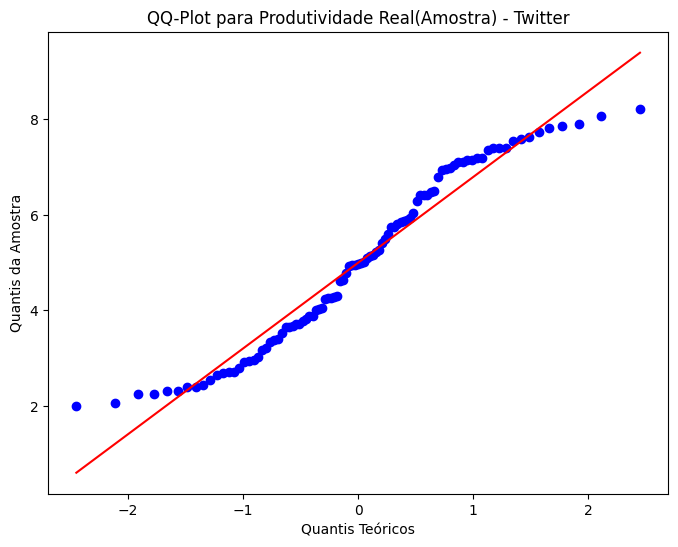


Rede Social: Telegram
Shapiro-Wilk: Estatística = 0.9724, p-valor = 0.0321
Rejeito H0 (dados da amostra não parecem normais)


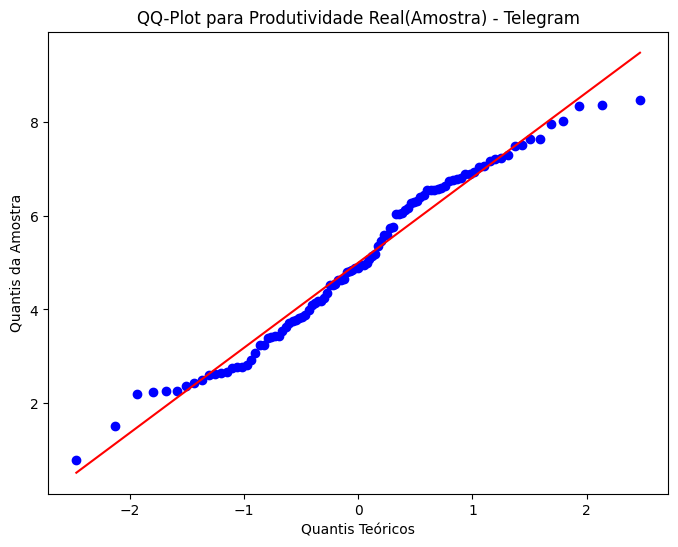


Rede Social: TikTok
Shapiro-Wilk: Estatística = 0.9550, p-valor = 0.0014
Rejeito H0 (dados da amostra não parecem normais)


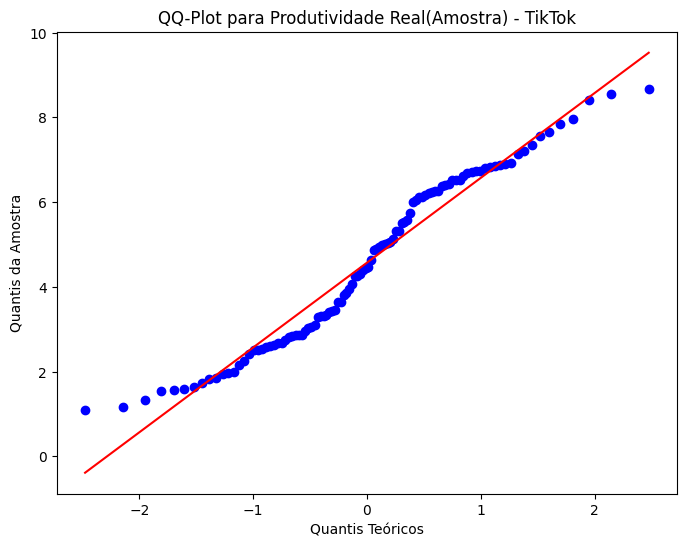


Rede Social: Instagram
Shapiro-Wilk: Estatística = 0.9748, p-valor = 0.0612
Não rejeito H0 (dados da amostra parecem normais)


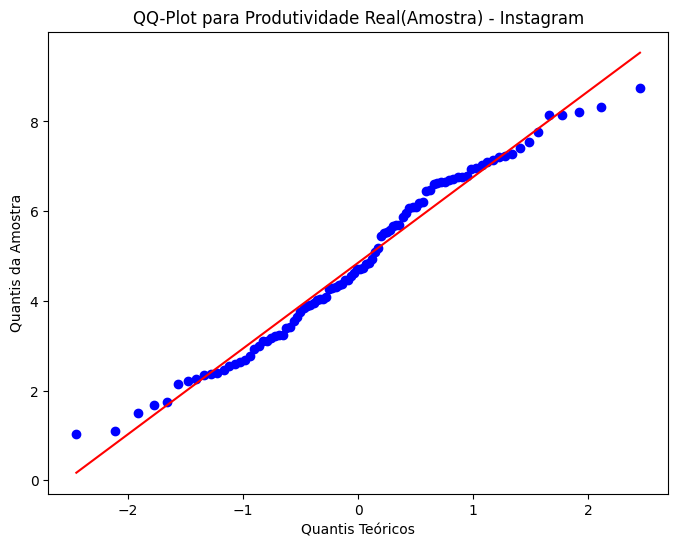


Rede Social: Facebook
Shapiro-Wilk: Estatística = 0.9412, p-valor = 0.0002
Rejeito H0 (dados da amostra não parecem normais)


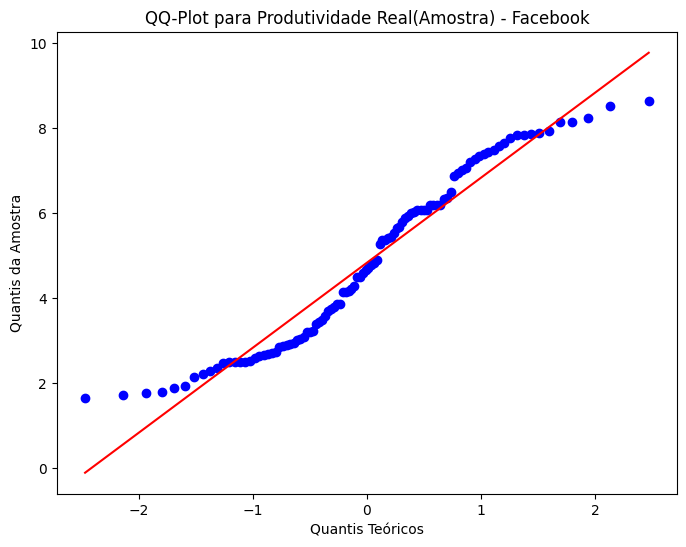

In [ ]:
print('---Teste de Normalidade por Rede Social(com amostragem) ---\n')
shapiro_resultado ={}
plataformas = amostra['social_platform_preference'].unique()

for plataforma in plataformas:
    print(f'\nRede Social: {plataforma}')
    #seleciona os dados da rede social
    dados = amostra[amostra['social_platform_preference']== plataforma]['actual_productivity_score']

    #Teste de Shapiro-Wilk
    if len(dados)>=3:
        estat_shapiro, p_shapiro = stats.shapiro(dados)
        shapiro_resultado[plataforma] = {'statistic':estat_shapiro,'p_value':p_shapiro}
        print(f'Shapiro-Wilk: Estatística = {estat_shapiro:.4f}, p-valor = {p_shapiro:.4f}')
        if p_shapiro > 0.05:
            print('Não rejeito H0 (dados da amostra parecem normais)')

        else:
            print('Rejeito H0 (dados da amostra não parecem normais)')
    else:
        print(f'Shapiro-Wilk: Não aplicável para {len(amostra)} amostras (deve ter no mínimo 3)')
        shapiro_resultado[plataforma] = {'statistic': np.nan, 'p_value': np.nan}

    #visualização da normalidade da amostra(QQ-PLOT)
    plt.figure(figsize=(8,6))

    stats.probplot(dados, dist="norm",plot=plt)

    plt.title(f'QQ-Plot para Produtividade Real(Amostra) - {plataforma}')
    plt.xlabel('Quantis Teóricos')
    plt.ylabel('Quantis da Amostra')

    plt.show()
    plt.close()

Com base nos resultados do teste de Shapiro-Wilk aplicado às amostras de 500 dados por plataforma:
*   Se o p-valor for > 0.05 para a maioria dos grupos, podemos considerar que os dados da amostra são aproximadamente normais e optar por um teste paramétrico (ANOVA).
*   Se o p-valor for <= 0.05 para a maioria dos grupos, os dados da amostra não são normais, e um teste não paramétrico (Kruskal-Wallis) é mais apropriado.

Vamos verificar os resultados para decidir


In [ ]:
#Vamos contar quantos grupos rejeitaram a normalidade
num_rejeicoes_normalidade = sum(1 for p in shapiro_resultado.values() if p['p_value']<= 0.05)


#Se mais da metade dos grupos rejeitar a normalidade:
if num_rejeicoes_normalidade/len(plataformas) > 0.5:
    print('Como mais da metade dos grupos rejeitou a normalidade dos dados,usar teste não paramétrico (Kruskal-Wallis)\n')
    dados_kruskal = []

    for plataforma in plataformas:
        dados_kruskal.append(df_limpo[df_limpo['social_platform_preference']==plataforma]['actual_productivity_score'])

    estat_teste,p_valor_teste = stats.kruskal(*dados_kruskal)
    nome_teste = "Kruskal-Wallis"
    h0_teste = "Não há diferença significativa na produtividade entre os grupos de plataformas de rede social"
    h1_teste = "Existe uma diferença significativa na produtividade entre pelo menos dois grupos de plataformas de rede social"
#Se mais da metade dos grupos não rejeitar a normalidade:
else:
    print('Como mais da metade dos grupos não rejeitou a normalidade dos dados, usar Teste Paramétrico (ANOVA)\n')
    print('Verificando homocedasticidade para ANOVA.')

    # Verificar homocedasticidade para ANOVA
    # H0:As variâncias dos grupos são iguais
    # H1:Pelo menos uma variância é diferente

    grupos_anova = [df_limpo[df_limpo['social_platform_preference'] == p]['actual_productivity_score'] for p in plataformas]

    estat_levene, p_levene = stats.levene(*grupos_anova)

    print(f'Teste de Levene (Homocedasticidade): Estatística = {estat_levene:.4f}, p-valor = {p_levene:.4f}')
    if p_levene >0.05:
        print('Não rejeito H0 (variâncias parecem homogêneas).Vamos usar ANOVA.')
        estat_teste,p_valor_teste = stats.f_oneway(*grupos_anova)
        nome_teste = "ANOVA"
        h0_teste = "Não há diferença significativa na produtividade entre os grupos de plataformas de rede social"
        h1_teste = "Existe uma diferença significativa na produtividade entre pelo menos dois grupos  de rede social"
    else:
        print('Rejeito H0 (variâncias não são homogêneas).')
        #Se as variâncias não são homogêneas,mesmo com normalidade, Kruskal-Wallis ainda é uma opção
        dados_kruskal =[]
        for plataforma in plataformas:

            dados_kruskal.append(df_limpo[df_limpo['social_platform_preference'] == plataforma]['actual_productivity_score'])

        estat_teste,p_valor_teste =stats.kruskal(*dados_kruskal)

        nome_teste ="Kruskal-Wallis"
        h0_teste ="Não há diferença significativa na produtividade entre os grupos "
        h1_teste = "Existe uma diferença significativa na produtividade entre pelo menos dois grupos"

print(f' Resultados do Teste do {nome_teste}\n')
print(f'Objetivo: Verificar se existe diferença significativa na pontuação de produtividade real entre indivíduos que utilizam diferentes plataformas de mídia social.\n')

print('Hipóteses:')
print(f'H0: {h0_teste}')
print(f'H1: {h1_teste}\n')


print("coclusao do teste:\n")
print(f'Resultados do Teste de {nome_teste}\nEstatística: {estat_teste:.4f}\nValor-p: {p_valor_teste:.4f}\n')


if p_valor_teste < 0.05:
    print(f'Rejeitamos H0.')
else:
    print('não rejeitamos H0.')

Como mais da metade dos grupos rejeitou a normalidade dos dados,usar teste não paramétrico (Kruskal-Wallis)

 Resultados do Teste do Kruskal-Wallis

Objetivo: Verificar se existe diferença significativa na pontuação de produtividade real entre indivíduos que utilizam diferentes plataformas de mídia social.

Hipóteses:
H0: Não há diferença significativa na produtividade entre os grupos de plataformas de rede social
H1: Existe uma diferença significativa na produtividade entre pelo menos dois grupos de plataformas de rede social

coclusao do teste:

Resultados do Teste de Kruskal-Wallis
Estatística: 1.8870
Valor-p: 0.7565

não rejeitamos H0.


### **Conclusão final**
A análise exploratória dos dados nos revelou que a pontuação de produtividade real
supostamente apresentava uma tendência para uma distribuição normal.No entanto, o
teste de normalidade de Shapiro-Wilk, aplicado a amostras de cada grupo de rede social,
indicou que a suposição de normalidade não era concreta para a maioria dos grupos.
Isso nos levou a optar por um teste não paramétrico(Kruskal-Wallis) para comparar os grupos.
O resultado do teste mostrou que não devemos rejeitar  a hipótese nula.
Isso significa que, com os dados disponíveis,nao tivemos evidências estatísticas suficientes para afirmar que a preferência por uma rede social
teve um impacto significativo na produtividade real dos indivíduos.Em
outras palavras, a plataforma que uma pessoa prefere usar não aparentou estar associada
a diferentes níveis de produtividade,pelo menos não de forma estatisticamente
significativa nesse conjunto de dados.


# **Teste para verificar a relação entre a produtividade e a quantidade de horas trabalhadas**

### **Teste de Normalidade**

Para descobrir qual teste estatístico é mais adequado, realizaremos o teste de Shapiro-Wilk para verificar a normalidade das variáveis (se aproximam-se de uma curva Normal).

H0: As amostras seguem uma distribuição normal.

H1: As amostras não seguem uma distribuição normal.


work_hours_per_day: Não rejeito a normalidade (p-valor = 0.38984870050157594)


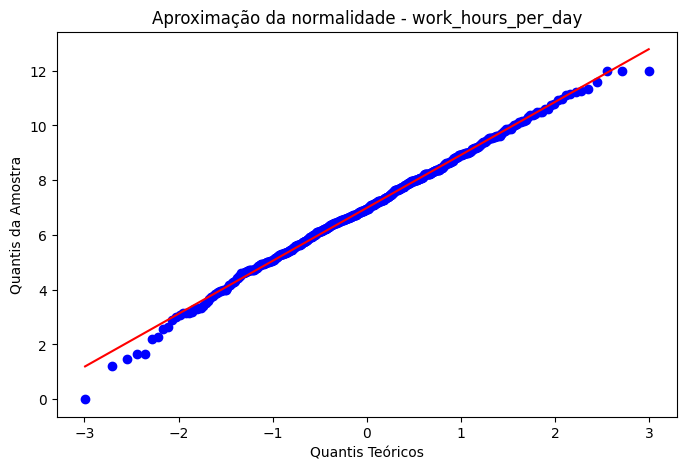


actual_productivity_score: Rejeito a normalidade (p-valor = 3.3078300257015205e-09)


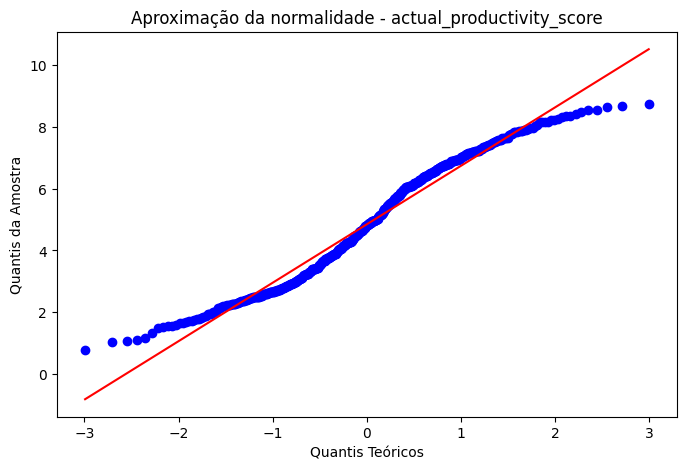

In [ ]:
# teste de Shapiro Wilk para normalidade

from scipy import stats

for coluna in ['work_hours_per_day', 'actual_productivity_score']:
    x = amostra[coluna]
    stat, p = stats.shapiro(x)
    if(p > 0.05):
      print(f'\n{coluna}: Não rejeito a normalidade (p-valor = {p})')
    else:
      print(f'\n{coluna}: Rejeito a normalidade (p-valor = {p})')

    #visualização da normalidade
    plt.figure(figsize=(8, 5))
    stats.probplot(amostra[coluna], dist="norm", plot=plt)
    plt.title(f'Aproximação da normalidade - {coluna}')
    plt.xlabel('Quantis Teóricos')
    plt.ylabel('Quantis da Amostra')
    plt.show()
    plt.close()

**Conclusão do teste de normalidade:** Como um dos p-valores para o teste de normalidade foi menor do que 0.05, rejeitamos a hipótese nula para 'actual_productivity_score'. Ou seja, temos evidências para afirmar que os dados dessa coluna não seguem uma distribuição Normal. Isso também é visível no gráfico, em que os pontos da amostra divergem da linha da Normal.

### **Teste para coeficiente de correlação**

Como um dos testes para normalidade foram rejeitados, utilizaremos o teste de correlação de Spearman para investigar a relação entre produtividade e a quantidade de horas trabalhadas.

H0: Não há correlação entre as variáveis (ρ = 0)

H1: Há correlação entre as variáveis (𝜌 ≠ 0)

Coeficiente de Spearman = 0.024866885854764577
p-valor = 0.5790762369996381
Não rejeito H0 - Não há evidência significativa de correlação linear.


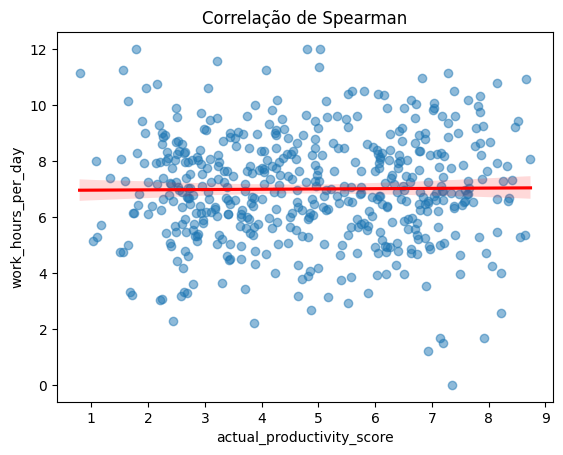

In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(amostra['actual_productivity_score'], amostra['work_hours_per_day'])

print(f"Coeficiente de Spearman = {rho}")
print(f"p-valor = {p}")

if p < 0.05:
    print("Rejeito H0 - há evidência significativa de correlação linear.")
else:
    print("Não rejeito H0 - Não há evidência significativa de correlação linear.")

sns.regplot(x=amostra['actual_productivity_score'], y=amostra['work_hours_per_day'], scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
plt.title(f"Correlação de Spearman")
plt.xlabel("actual_productivity_score")
plt.ylabel("work_hours_per_day")
plt.show()

### **Conclusão final**

Para averiguar se havia correlação entre a produtividade e a quantidade de horas trabalhadas, primeiro testamos a normalidade utilizando o teste de Shapiro-Wilk para as variáveis 'actual_productivity_score' e 'work_hours_per_day'. Como uma delas rejeitou a normalidade, utilizamos o teste não-paramétrico para coeficiente de correlação de Spearman. Nele, o p-valor foi maior do que 0.05, o que nos leva a não rejeitar H0. Isso significa que não temos evidências para rejeitar a ideia de que as duas variáveis não estão correlacionadas.

# **Teste para investigar a relação entre a quantidade de horas de sono e a de horas de trabalho**

### **Teste de normalidade**

Para descobrir qual teste estatístico é mais adequado, realizaremos o teste de Shapiro-Wilk para verificar a normalidade das variáveis (se aproximam-se de uma curva Normal).

H0: As amostras seguem uma distribuição normal.

H1: As amostras não seguem uma distribuição normal.


work_hours_per_day: Não rejeito a normalidade (p-valor = 0.38984870050157594)


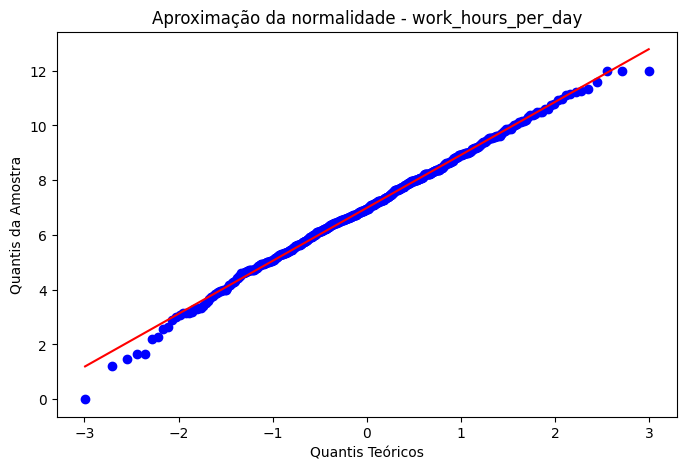


sleep_hours: Não rejeito a normalidade (p-valor = 0.09701988057544335)


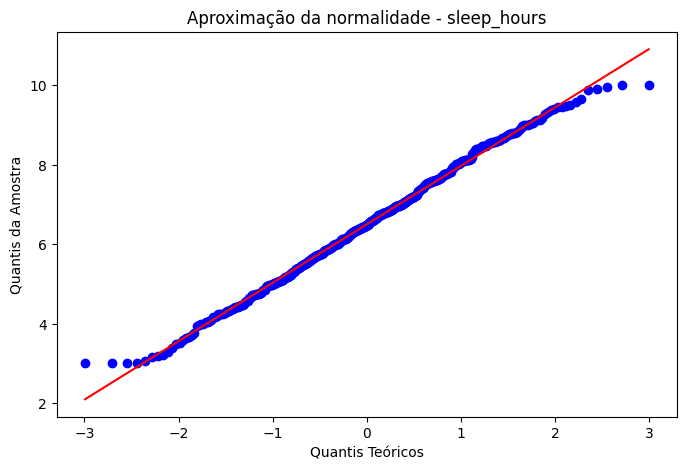

In [ ]:
# teste de Shapiro Wilk para normalidade

from scipy import stats

for coluna in ['work_hours_per_day', 'sleep_hours']:
    x = amostra[coluna]
    stat, p = stats.shapiro(x)
    if(p > 0.05):
      print(f'\n{coluna}: Não rejeito a normalidade (p-valor = {p})')
    else:
      print(f'\n{coluna}: Rejeito a normalidade (p-valor = {p})')

    #visualização da normalidade
    plt.figure(figsize=(8, 5))
    stats.probplot(amostra[coluna], dist="norm", plot=plt)
    plt.title(f'Aproximação da normalidade - {coluna}')
    plt.xlabel('Quantis Teóricos')
    plt.ylabel('Quantis da Amostra')
    plt.show()
    plt.close()

**Conclusão do teste de normalidade:** como o p-valor de ambos é maior do que 0.05 (p-valor > 0.05), não rejeitamos a hipótese nula H0. Ou seja, não há evidências para rejeitar a normalidade das variáveis 'work_hours_per_day' e 'sleep_hours' na amostra. Isso também é visível nos gráficos, na qual os pontos da amostras se aproximam da reta linear da Normal.

### **Teste para coeficiente de correlação**

Como ambas as variáveis seguem uma distribuição aproximadamente Normal, utilizaremos o teste para coeficiente de correlação de Pearson para verificar se as variáveis estão associadas entre si ou não.

H0: Não há correlação entre as variáveis (ρ = 0)

H1: Há correlação entre as variáveis (𝜌 ≠ 0)

Coeficiente de correlação r = 0.028469787950509667
p-valor = 0.5253376198878663
Não rejeito H0 - não há evidências de correlação linear.


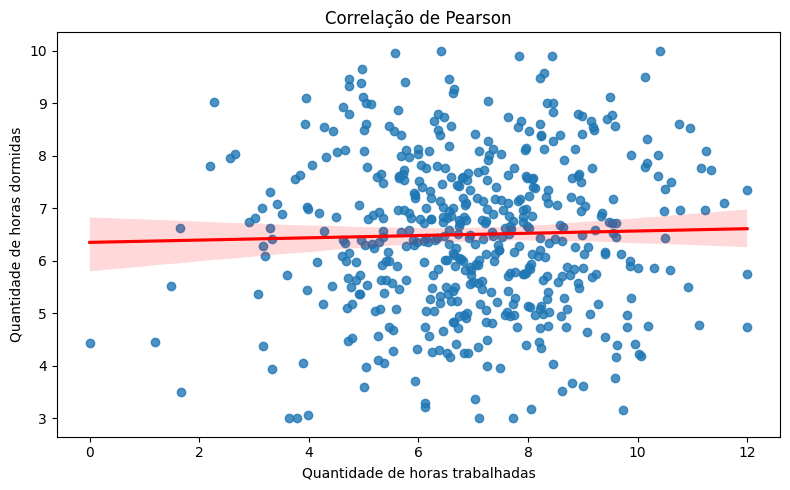

In [ ]:
from scipy.stats import pearsonr

# Teste de correlação de Pearson
r, p_valor = pearsonr(amostra['work_hours_per_day'], amostra['sleep_hours'])

print(f"Coeficiente de correlação r = {r}")
print(f"p-valor = {p_valor}")

if p_valor < 0.05:
    print("Rejeito H0 - há evidência significativa de correlação linear.")
else:
    print("Não rejeito H0 - não há evidências de correlação linear.")

# Visualização do resultado do teste - gráfico de dispersão com linha de regressão
plt.figure(figsize=(8, 5))
sns.regplot(x=amostra['work_hours_per_day'], y=amostra['sleep_hours'], line_kws={'color': 'red'})
plt.title(f"Correlação de Pearson")
plt.xlabel("Quantidade de horas trabalhadas")
plt.ylabel("Quantidade de horas dormidas")
plt.tight_layout()
plt.show()

### **Conclusão Final**

Para verificar se há correlação entre a quantidade de horas trabalhadas e a de horas de sono, primerio tivemos que aplicar um teste de normalidade, que no caso, foi escolhido o Shapiro-Wilk, para descobrir se seria aplicado um teste paramétrico ou não-paramétrico. Como as variáveis não rejeitaram a normalidade, aplicamos o teste paramétrico para o coeficiente de correlação de Pearson. Esse teste resultou num p-valor maior do que 0.05, portanto não rejeitamos a hipótese nula. Ou seja, não temos evidências para rejeitar a hipótese de que a quantidade de horas trabalhadas e de horas dormidas não estão correlacionadas.

# **Teste para verificar a relação entre o gênero e a quantidade de horas trabalhadas**

In [ ]:
amostra['gender'].value_counts()

,count
gender,
Female,245
Male,232
Other,23


Como a categoria 'others' ficou com poucos observações, ela será retirada da análise e focaremos na relação de horas trabalhadas entre homens e mulheres.

In [ ]:
#excluindo linhas da amostra em que o gênero
amostra_teste = amostra[amostra['gender'].isin(['Female', 'Male'])]
amostra_teste

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
3661,36,Female,Student,5.127717,Twitter,69,7.979210,2.646607,2.321966,2.0,7.568008,0.330345,8,True,False,2,23,15.221973,3.132537
13279,21,Female,Health,1.352347,Telegram,74,10.173016,6.982860,6.639901,4.0,8.328132,1.368552,6,False,True,2,1,16.120166,6.200354
29735,23,Female,Student,4.938801,TikTok,73,7.729134,3.072162,2.423302,9.0,5.171517,0.452840,6,False,False,3,15,5.420083,2.196394
14700,36,Female,Unemployed,10.832153,Twitter,62,8.324962,2.951966,2.643793,1.0,7.222108,1.379074,4,False,False,3,25,17.623549,0.344564
7091,41,Male,Finance,3.672656,Instagram,58,5.334852,3.881889,3.242198,8.0,5.920233,0.608256,5,True,False,1,15,0.859844,5.352764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22790,48,Female,Unemployed,3.945927,Facebook,57,9.085522,2.652034,3.021248,3.0,4.641187,0.156878,8,True,False,0,7,0.000000,2.810902
25944,18,Female,Student,3.208933,Telegram,56,4.183471,2.845339,2.613213,10.0,6.904272,1.323652,2,False,False,2,21,23.107491,2.646055
8107,36,Male,Unemployed,1.875952,Telegram,66,5.248204,7.158184,6.883555,5.0,7.595462,0.000000,1,False,False,2,25,6.138754,5.743424
22620,62,Male,IT,3.318898,TikTok,62,5.357570,5.383148,3.848019,8.0,6.448238,1.017036,5,False,False,2,24,16.866316,2.981351


### **Teste de normalidade e de homocedasticidade**

Para descobrir qual teste estatístico é mais adequado, realizaremos o teste de Shapiro-Wilk para verificar a normalidade das variáveis (se aproximam-se de uma curva Normal) e o teste de Levene para verificar a homogeneidade das variâncias (homocedasticidade).

*Teste de Shapiro-Wilk*

H0: As amostras seguem uma distribuição normal.

H1: As amostras não seguem uma distribuição normal.


Female: Não rejeito a normalidade (p-valor = 0.7848305161258047)


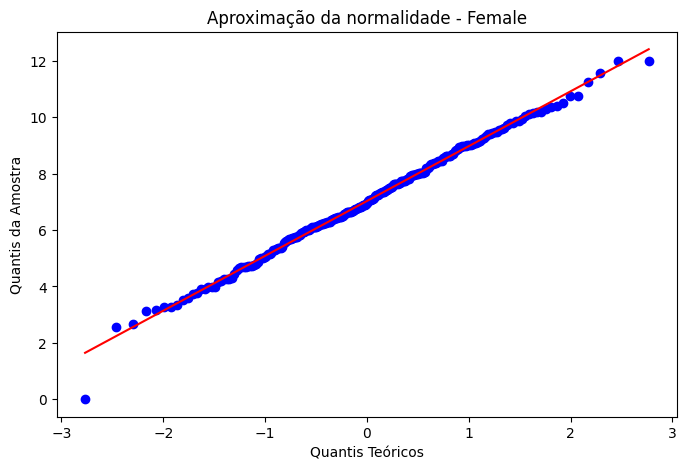


Male: Não rejeito a normalidade (p-valor = 0.18939748840046683)


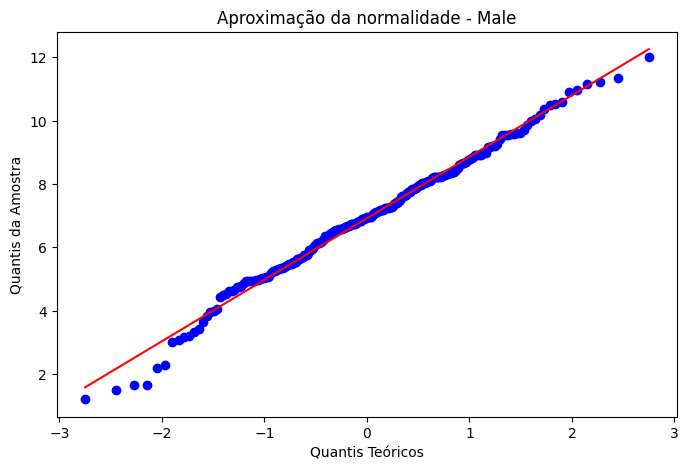

In [ ]:
# Teste de Shapiro-Wilk para normalidade

for genero in amostra_teste['gender'].unique():
    grupo = amostra_teste[amostra_teste['gender'] == genero]['work_hours_per_day']
    stat, p = stats.shapiro(grupo)
    if(p > 0.05):
      print(f'\n{genero}: Não rejeito a normalidade (p-valor = {p})')
    else:
      print(f'\n{genero}: Rejeito a normalidade (p-valor = {p})')

    #visualização da normalidade
    plt.figure(figsize=(8, 5))
    stats.probplot(grupo, dist="norm", plot=plt)
    plt.title(f'Aproximação da normalidade - {genero}')
    plt.xlabel('Quantis Teóricos')
    plt.ylabel('Quantis da Amostra')
    plt.show()
    plt.close()

**Conclusão do teste de normalidade:** como o p-valor de todas as categorias é maior do que 0.05 (p-valor > 0.05), não rejeitamos a hipótese nula H0. Ou seja, não há evidências para rejeitar a normalidade de 'work_hours_per_day' das categorias em 'gender'. Isso também é visível nos gráficos, na qual os pontos da amostras se aproximam da reta linear da Normal.

*Teste de Levene*

H0: as variâncias de todos os grupos são iguais.

H1: pelo menos uma das variâncias é diferente.

Não rejeito a homocedasticidade (p-valor = 0.6513291128859233)


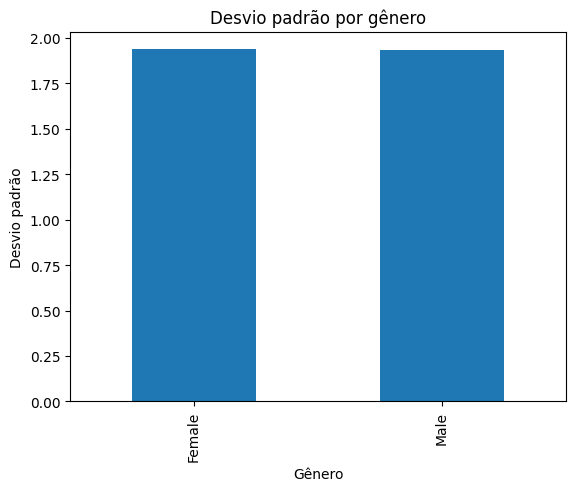

In [ ]:
# Teste de Levene para homogeneidade de variâncias
grupos = [amostra_teste[amostra_teste['gender'] == genero]['work_hours_per_day'] for genero in amostra_teste['gender'].unique()]
stat, p = stats.levene(*grupos)
if(p > 0.05):
  print(f'Não rejeito a homocedasticidade (p-valor = {p})')
else:
  print(f'Rejeito a homocedasticidade (p-valor = {p})')

# Visualizar os desvios-padrões
desvios = amostra_teste.groupby('gender')['work_hours_per_day'].std()
desvios.plot(kind='bar')
plt.title("Desvio padrão por gênero")
plt.ylabel("Desvio padrão")
plt.xlabel("Gênero")
plt.show()

**Conclusão do teste de homocedasticidade:** Como o p-valor é maior do que 0.05, não rejeitamos a hipótese nula H0. Ou seja, não temos evidências na amostra para rejeitar a ideia de que as variâncias dos grupos são iguais. Isso também é visível no gráfico de barras que mostra as variâncias de 'work_hours_per_day' por grupo('gender').

### **Teste t de student**

Como ambos os grupos ('Female' e 'Male') não rejeitaram a normalidade e a homecedasticidade de 'work_hours_per_day', utilizaremos o teste t de student para comparar as duas médias.

H0: as médias de horas trabalhadas de homens e mulheres são iguais. (μ1 = μ2)

H1: as médias são diferentes. (μ1 ≠ μ2)

Estatística t = 0.6564857038537938
p-valor = 0.5118295647498978
Não rejeito H0 - não há diferença significativa entre as médias.


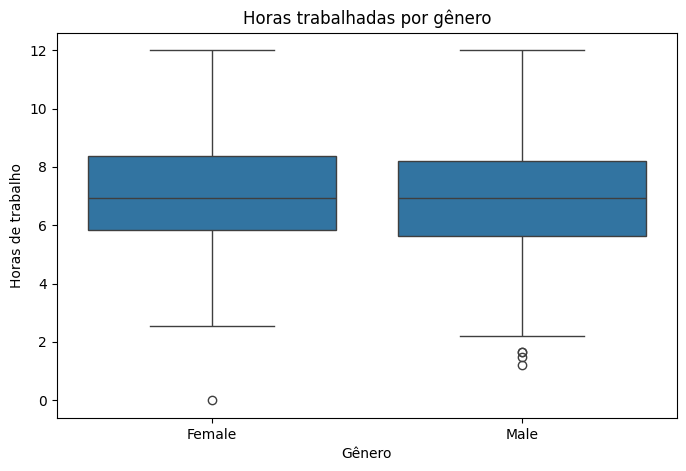

In [ ]:
from scipy.stats import ttest_ind

genders = amostra_teste.groupby("gender")

t_stat, p = ttest_ind(genders.get_group("Female")['work_hours_per_day'], genders.get_group("Male")['work_hours_per_day'], equal_var=True)

print(f'Estatística t = {t_stat}')
print(f'p-valor = {p}')

if p < 0.05:
    print("Rejeito H0 - há diferença entre as médias.")
else:
    print("Não rejeito H0 - não há diferença significativa entre as médias.")

plt.figure(figsize=(8, 5))
sns.boxplot(x=amostra_teste['gender'], y=amostra_teste['work_hours_per_day'], data=amostra_teste)
plt.title("Horas trabalhadas por gênero")
plt.xlabel("Gênero")
plt.ylabel("Horas de trabalho")
plt.show()

In [ ]:
amostra_teste.groupby("gender").describe()

age                                                      \
        count       mean        std   min   25%   50%   75%   max   
gender                                                              
Female  245.0  40.412245  13.659105  18.0  29.0  40.0  52.0  65.0   
Male    232.0  42.788793  13.830240  18.0  32.0  44.0  54.0  65.0   

       daily_social_media_time            ... weekly_offline_hours             \
                         count      mean  ...                  75%        max   
gender                                    ...                                   
Female                   245.0  3.321723  ...             14.80125  33.585258   
Male                     232.0  3.149415  ...             15.75627  28.946144   

       job_satisfaction_score                                          \
                        count      mean       std       min       25%   
gender                                                                  
Female                  245.0  4.969711  2.022310  0.045191  3.452432   
Male                    232.0  4.798085  2.179706  0.148055  3.120185   

                                       
             50%       75%        max  
gender                                 
Female  5.022103  6.429570   9.580895  
Male    4.769968  6.600191  10.000000  

[2 rows x 112 columns]

### **Conclusão final**

A fim de verificar a relação entre o gênero e a quantidade de horas trabalhadas, primeiro tivemos que verificar a normalidade (teste de Shapiro_Wilk) e a homocedasticidade (teste de Levene) das variáveis, para descobrir qual teste de comparação de médias seria mais adequado. Como nenhum dos dois foi rejeitado, aplicamos o teste t de Student. Nele, foi encontrado um p-valor maior do que 0.05, de forma a não rejeitarmos H0. Isso significa que não há diferenças significativas na quantidade de horas trabalhadas entre homens e mulheres (ambos trabalham, aproximadamente, por um mesmo período de tempo).